<a href="https://colab.research.google.com/github/Manojmp7676/NATURAL-LANGUAGE-PROCESSING-NLP-/blob/main/NLP_first.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd#regular expressions cleaning
import numpy as np#for basics
import re#egular expresion for cleaning the data
import nltk#for basics
import matplotlib.pyplot as plt#visuvalization
from nltk.corpus import stopwords# to reomove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud # Corrected: import WordCloud class

In [44]:
# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [45]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("customer review dataset")
print(df.head())

customer review dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [46]:
stop_words= set(stopwords.words('english'))

def clean_text(text):

  #convert to lowercase
  text=text.lower()
  print('lower case',text)

#remove special character and number
  text =re.sub(r'[^a-zA-Z\s]','',text)
  print('special character',text)

  #tokenization
  words=word_tokenize(text)
  print('tokenization',words)

#remove stopwords
  words=[word for word in words if word not in stop_words]
  print('stop words',words)

#join words again
  cleaned_text=" ".join(words)

  return cleaned_text

df['cleaned_review']=df['Review'].apply(clean_text)

print("\n cleaned reviews")
print(df[['Review','cleaned_review']])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delive

In [48]:
sia=SentimentIntensityAnalyzer()

def get_sentiment_score(review):
  score=sia.polarity_scores(review)
  compound=score['compound']

  if compound>=0.05:
    return "positive"

  elif compound <=-0.05:
    return "Negative"

  else:
    return "neutral"

#apply sentiment analysis
df['sentiment']=df['cleaned_review'].apply(get_sentiment_score)
print("\n sentiment analysis")
print(df[['Review','sentiment']])


 sentiment analysis
                                              Review sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  Negative


find common keywords


In [49]:
all_words=" ".join(df['cleaned_review'])
words_list = all_words.split()


#count word frequently
word_freq = Counter(words_list)

#display top 10 keywords
print("\n top 10 common keywords")
print(word_freq.most_common(10))


 top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


identify common complaints


In [50]:
negative_reviews=df[df['sentiment']=='Negative']
negative_words=" ".join(negative_reviews['cleaned_review'])
negative_words_list=negative_words.split()
complaint_freq=Counter(negative_words_list)
print("\n most  common complaints keywords")
print(complaint_freq.most_common(10))


 most  common complaints keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


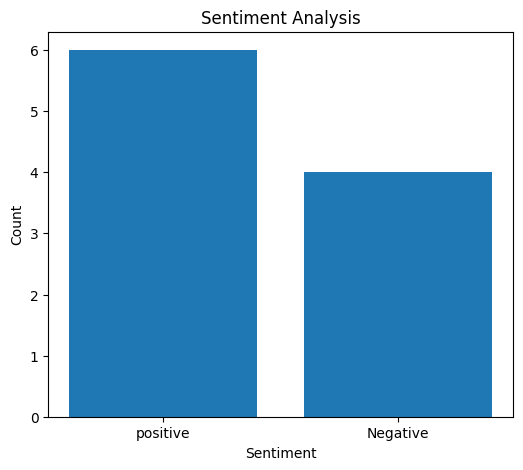

In [51]:
sentiment_counts=df['sentiment'].value_counts()#it will give category count

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis')
plt.show()

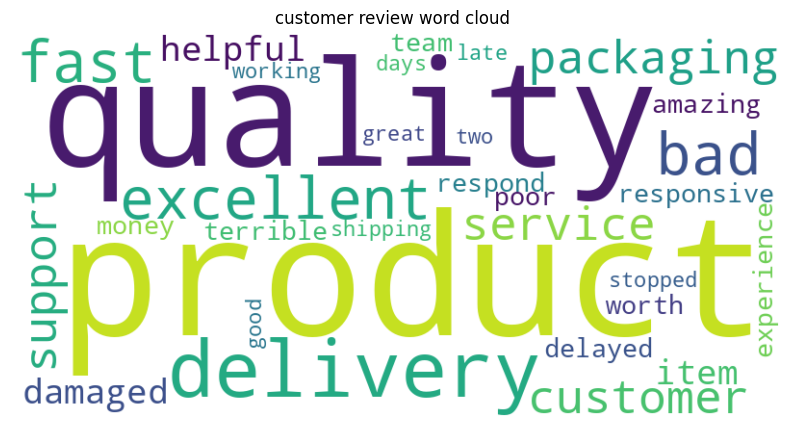

In [53]:
WordCloud_obj=WordCloud(width=800,height=400,background_color='white').generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(WordCloud_obj,interpolation='bilinear') # Corrected: Use WordCloud_obj here
plt.axis('off')
plt.title("customer review word cloud ")
plt.show()